In [1]:
import json

import geopandas as gpd
import laspy
import matplotlib.pyplot as plt
import numpy as np
import pdal
from scipy.spatial import cKDTree, Delaunay
from shapely.geometry import Point

from src.functions import estimer_z_toit

In [2]:
laz_path = "../data/tuile_1.laz"
las = laspy.read(laz_path)

x = las.x
y = las.y
z = las.z

classes = np.array(las.classification)

In [3]:
geodf = gpd.read_file("../outputs/buildings_emprises_2.geojson")
geodf = geodf.to_crs("EPSG:2154")

building_id = 933  # Je choisis ma maison

emprise = geodf.iloc[building_id].geometry

print('Type de géométrie : ', emprise.geom_type)
print('Surface : ', emprise.area)

Type de géométrie :  Polygon
Surface :  154.2817000021947


In [4]:
print(geodf.crs)
print(emprise.bounds)

EPSG:2154
(628870.84, 6881577.12, 628885.48, 6881591.68)


In [5]:
maison = emprise.buffer(2)
maison = maison.wkt

pipeline_dict = [
    laz_path,
    {
        "type": "filters.crop",
        'polygon': maison
    }
]

pipeline_json = json.dumps(pipeline_dict)
pipeline = pdal.Pipeline(pipeline_json)
pipeline.execute()

result = pipeline.arrays[0]
print('Nombre de points extraits : ', len(result))
print('Champs dispos : ', result.dtype.names)

Nombre de points extraits :  5283
Champs dispos :  ('X', 'Y', 'Z', 'Intensity', 'ReturnNumber', 'NumberOfReturns', 'ScanDirectionFlag', 'EdgeOfFlightLine', 'Classification', 'Synthetic', 'KeyPoint', 'Withheld', 'Overlap', 'ScanAngleRank', 'UserData', 'PointSourceId', 'GpsTime', 'ScanChannel')


In [6]:
X = result['X']
Y = result['Y']
Z = result['Z']
Classification = result['Classification']

maison_mask = Classification == 6
sol_mask = Classification == 2

x_m, y_m, z_m = X[maison_mask], Y[maison_mask], Z[maison_mask]
x_s, y_s, z_s = X[sol_mask], Y[sol_mask], Z[sol_mask]

print('Points bâtiments : ', len(x_m))
print('Points sol : ', len(x_s))

Points bâtiments :  2892
Points sol :  1360


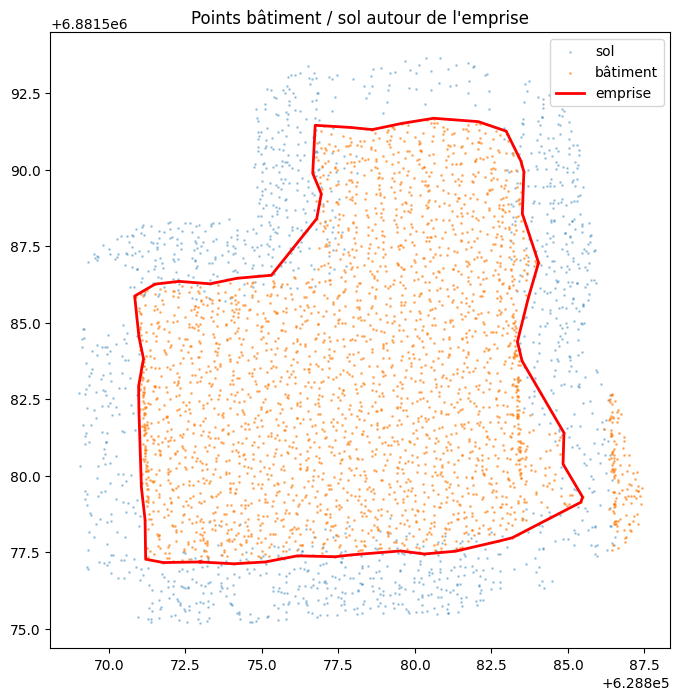

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(x_s, y_s, s=1, alpha=0.3, label="sol")
ax.scatter(x_m, y_m, s=1, alpha=0.5, label="bâtiment")
x_fp, y_fp = emprise.exterior.xy
ax.plot(x_fp, y_fp, color="red", linewidth=2, label="emprise")

ax.set_title("Points bâtiment / sol autour de l'emprise")
ax.legend()
ax.axis("equal")
plt.show()

In [8]:
z_sol = float(np.median(z_s))
print('Altitude (m) : ', z_sol)

Altitude (m) :  96.29


In [9]:
emprise_coords = np.array(emprise.exterior.coords)
print('Nombre de sommet du contour : ', len(emprise_coords))

Nombre de sommet du contour :  47


In [10]:
toit_tree = cKDTree(np.column_stack([x_m, y_m]))
emprise_haut = []

for xy in emprise_coords:
    z_temp = estimer_z_toit(xy, toit_tree, z_m)
    emprise_haut.append([xy[0], xy[1], z_temp])

emprise_haut = np.array(emprise_haut)
emprise_sol = np.column_stack([
    emprise_coords[:, 0],
    emprise_coords[:, 1],
    np.full(len(emprise_coords), z_sol)
])

print('Contour haut : ', emprise_haut.shape)
print('Contour sol : ', emprise_sol.shape)

Contour haut :  (47, 3)
Contour sol :  (47, 3)


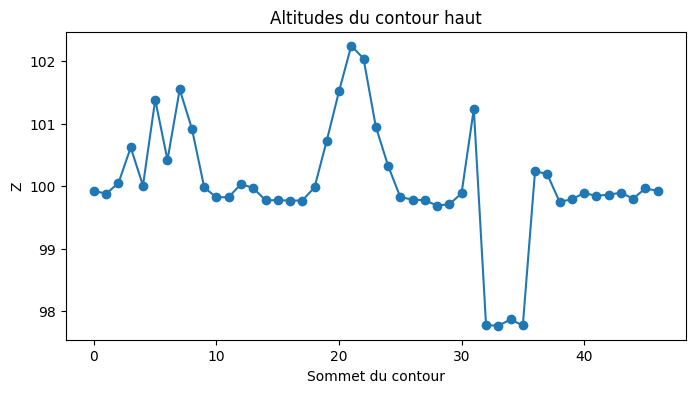

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(emprise_haut[:, 2], marker="o")
plt.title("Altitudes du contour haut")
plt.xlabel("Sommet du contour")
plt.ylabel("Z")
plt.show()

In [12]:
toit_points = np.column_stack([x_m, y_m, z_m])
toit_points_all = np.vstack([toit_points, emprise_sol])
print("Points de toit pour triangulation :", toit_points_all.shape)

Points de toit pour triangulation : (2939, 3)


In [13]:
xy_toit = toit_points_all[:, :2]
tri = Delaunay(xy_toit)
triangles = tri.simplices
print("Triangles bruts :", len(triangles))

Triangles bruts : 457


In [14]:
triangles_clean = []

for triangle in triangles:
    triangle_coords = xy_toit[triangle]
    centre = triangle_coords.mean(axis=0)

    if emprise.contains(Point(centre[0], centre[1])):
        triangles_clean.append(triangle)

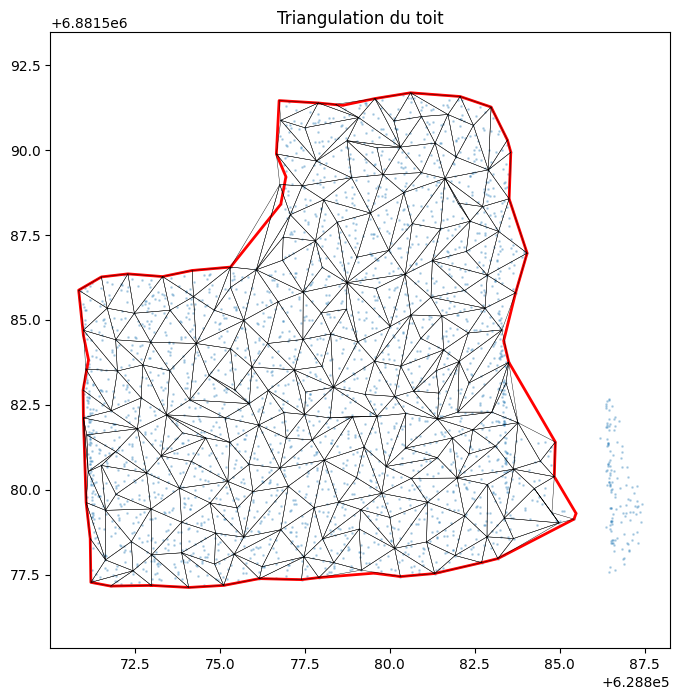

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x_m, y_m, s=1, alpha=0.25)

x_fp, y_fp = emprise.exterior.xy
ax.plot(x_fp, y_fp, color="red", linewidth=2)

for triangle in triangles_clean:
    pts = xy_toit[triangle]
    pts_closed = np.vstack([pts, pts[0]])
    ax.plot(pts_closed[:, 0], pts_closed[:, 1], color="black", linewidth=0.3)

ax.set_title("Triangulation du toit")
ax.axis("equal")
plt.show()

In [16]:
sommets = []
sommets_map = {}


def ajout_sommet(s, precision=3):
    cle = tuple(np.round(s, precision))
    if cle not in sommets_map:
        sommets_map[cle] = len(sommets)
        sommets.append(list(map(float, s)))
    return sommets_map[cle]

In [17]:
sol = [ajout_sommet(s) for s in emprise_sol]

In [18]:
murs = []

n = len(emprise_coords)
for i in range(n):
    j = (i + 1) % n

    g1 = ajout_sommet(emprise_sol[i])
    g2 = ajout_sommet(emprise_sol[j])
    t2 = ajout_sommet(emprise_haut[j])
    t1 = ajout_sommet(emprise_haut[i])

    murs.append([g1, g2, t2, t1])

In [19]:
toit = []

for triangle in triangles_clean:
    surface = []
    for coord in triangle:
        s = toit_points_all[coord]
        surface.append(ajout_sommet(s))
    toit.append(surface)

In [20]:
boundaries = []
semantic_surfaces = []
semantic_values = []

# Toit
for surf in toit:
    boundaries.append([surf])
    semantic_surfaces.append({"type": "RoofSurface"})
    semantic_values.append(len(semantic_surfaces) - 1)

# Murs
for surf in murs:
    boundaries.append([surf])
    semantic_surfaces.append({"type": "WallSurface"})
    semantic_values.append(len(semantic_surfaces) - 1)

# Sol
boundaries.append([sol])
semantic_surfaces.append({"type": "GroundSurface"})
semantic_values.append(len(semantic_surfaces) - 1)

print("Nombre total de surfaces :", len(boundaries))

Nombre total de surfaces : 446


In [21]:
sommets_np = np.array(sommets, dtype=float)

scale = np.array([0.001, 0.001, 0.001], dtype=float)
translate = sommets_np.min(axis=0)

sommets_encoded = np.round((sommets_np - translate) / scale).astype(int)

print("Nombre de sommets :", len(sommets_encoded))
print("Translate :", translate)
print("Scale :", scale)

Nombre de sommets : 296
Translate : [6.28870840e+05 6.88157712e+06 9.62900000e+01]
Scale : [0.001 0.001 0.001]


In [22]:
cityjson = {
    "type": "CityJSON",
    "version": "2.0",
    "CityObjects": {
        f"maison": {
            "type": "Building",
            "geometry": [
                {
                    "type": "MultiSurface",
                    "lod": "2",
                    "boundaries": boundaries,
                    "semantics": {
                        "surfaces": semantic_surfaces,
                        "values": semantic_values
                    }
                }
            ]
        }
    },
    "transform": {
        "scale": scale.tolist(),
        "translate": translate.tolist()
    },
    "vertices": sommets_encoded.tolist(),
    "metadata": {
        "identifier": f"maison",
        "referenceSystem": "http://www.opengis.net/def/crs/EPSG/0/2154"
    }
}

In [23]:
cityjson_path = f"../outputs/maison.city.json"

with open(cityjson_path, "w", encoding="utf-8") as f:
    json.dump(cityjson, f, indent=2)

print("CityJSON écrit :", cityjson_path)

CityJSON écrit : ../outputs/maison.city.json


In [24]:
with open(cityjson_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Type :", data["type"])
print("Version :", data["version"])
print("Nombre de CityObjects :", len(data["CityObjects"]))
print("Nombre de sommets :", len(data["vertices"]))
print("Clé bâtiment :", list(data["CityObjects"].keys())[0])

Type : CityJSON
Version : 2.0
Nombre de CityObjects : 1
Nombre de sommets : 296
Clé bâtiment : maison
